# Multi-Modal RAG on Databricks

This notebook demonstrates an end-to-end multi-modal Retrieval-Augmented Generation (RAG) pipeline using Databricks AI Functions and Mosaic AI Vector Search.

## Architecture

1. **Ingest** — PDFs stored in a Unity Catalog Volume
2. **Parse** — `ai_parse_document()` extracts text, tables, and figures; page images are rendered to a Volume
3. **Chunk** — `ai_prep_search()` produces context-enriched chunks with image URIs
4. **Store** — Flatten chunks into a Delta table (`chunk_id`, `chunk_to_embed`, `chunk_to_retrieve`, `pages`, `source_uri`)
5. **Index** — Mosaic AI Vector Search keeps the index in sync with the Delta table
6. **Query** — At inference time, search the index, retrieve top chunks, and if the question is visual, pass page images + text to a vision model

In [0]:
# Configuration
CATALOG = "jennifer_wang"
SCHEMA = "usb_classification"
VOLUME_PDFS = f"/Volumes/{CATALOG}/{SCHEMA}/pdfs"              # Source PDFs
VOLUME_IMAGES = f"/Volumes/{CATALOG}/{SCHEMA}/page_images"     # Rendered page images output

# Delta table for search-ready chunks
CHUNKS_TABLE = f"{CATALOG}.{SCHEMA}.rag_chunks"

# Vector Search
VS_ENDPOINT = "jennifer-test"
VS_INDEX = f"{CATALOG}.{SCHEMA}.rag_chunks_index"

print(f"Source PDFs:    {VOLUME_PDFS}")
print(f"Image output:   {VOLUME_IMAGES}")
print(f"Chunks table:   {CHUNKS_TABLE}")
print(f"VS endpoint:    {VS_ENDPOINT}")
print(f"VS index:       {VS_INDEX}")

Source PDFs:    /Volumes/jennifer_wang/usb_classification/pdfs
Image output:   /Volumes/jennifer_wang/usb_classification/page_images
Chunks table:   jennifer_wang.usb_classification.rag_chunks
VS endpoint:    multimodal_rag_endpoint
VS index:       jennifer_wang.usb_classification.rag_chunks_index


## Step 1: Parse Documents

`ai_parse_document()` extracts text, tables, and figures from each PDF. Setting `imageOutputPath` renders each page as an image into a UC Volume, and `descriptionElementTypes = '*'` generates AI descriptions for figures.

In [0]:
%sql
-- Create the page images output volume if it doesn't exist
CREATE VOLUME IF NOT EXISTS jennifer_wang.usb_classification.page_images;

In [0]:
%sql
CREATE OR REPLACE TABLE jennifer_wang.usb_classification.parsed_documents AS
SELECT
  path,
  ai_parse_document(
    content,
    MAP(
      'version', '2.0',
      'imageOutputPath', '/Volumes/jennifer_wang/usb_classification/page_images/',
      'descriptionElementTypes', '*'
    )
  ) AS parsed
FROM READ_FILES(
  '/Volumes/jennifer_wang/usb_classification/pdfs/',
  format => 'binaryFile'
);

num_affected_rows,num_inserted_rows


In [0]:
%sql
-- Inspect figure elements and their AI-generated descriptions
SELECT
  *
FROM
  jennifer_wang.usb_classification.parsed_documents
LIMIT 10;

path parsed dbfs:/Volumes/jennifer_wang/usb_classification/pdfs/AUSB0206-K001C11_1A.PDF {"document":{"elements":[{"bbox":[{"coord":[26,194,68,227],"page_id":0}],"confidence":0.9955,"content":"F","description":null,"id":0,"type":"text"},{"bbox":[{"coord":[26,341,65,371],"page_id":0}],"confidence":0.9892,"content":"E","description":null,"id":1,"type":"text"},{"bbox":[{"coord":[26,583,63,612],"page_id":0}],"confidence":0.9949,"content":"D","description":null,"id":2,"type":"text"},{"bbox":[{"coord":[26,847,63,876],"page_id":0}],"confidence":0.9505,"content":"C","description":null,"id":3,"type":"text"},{"bbox":[{"coord":[26,1088,63,1118],"page_id":0}],"confidence":0.9917,"content":"B","description":null,"id":4,"type":"text"},{"bbox":[{"coord":[26,1332,63,1362],"page_id":0}],"confidence":0.9862,"content":"A","description":null,"id":5,"type":"text"},{"bbox":[{"coord":[227,205,684,673],"page_id":0}],"confidence":0.8901,"content":"DATE CODE\nLOTES\nXXXX\n13.50REF\n16.35 ref\n6.00\n14.60 ref","description":"The diagram presents a rectangular object with protruding features, labeled \"Lotes\" and \"XXXX,\" alongside dimension markings.","id":6,"type":"figure"},{"bbox":[{"coord":[854,308,1261,563],"page_id":0}],"confidence":0.3201,"content":"L875","description":"The image presents a detailed line drawing of a complex, angled mechanical device labeled \"LOTES.\"","id":7,"type":"figure"},{"bbox":[{"coord":[277,727,809,1225],"page_id":0}],"confidence":0.8753,"content":"1.84±0.05\n0.15 A\n4.13\n-A-\n0.40(4x)\n0.15 C\n13.85ref\n15.47\nSEE DETAIL Y","description":"A technical drawing shows a circular component with multiple internal features and labeled dimensions.","id":8,"type":"figure"},{"bbox":[{"coord":[817,808,1243,1146],"page_id":0}],"confidence":0.8498,"content":"7.77\n11.78±0.20\n2.00±0.05\n2.00\n6.97\n2.20±0.15\n0.20±0.05\n0.15\nB\nB","description":"A technical diagram shows a rectangular object with various dimensions labeled, including 7.77, 6.97, and 11.78.","id":9,"type":"figure"},{"bbox":[{"coord":[493,1249,1235,1563],"page_id":0}],"confidence":0.8837,"content":"3.10(REF) 10.5 8.88 USB PLUG CONNECTOR RECOMMENDED METHOD OF MATE","description":"A cross-section diagram illustrates a USB plug and connector with labeled dimensions and internal components.","id":10,"type":"figure"},{"bbox":[{"coord":[734,1559,833,1583],"page_id":0}],"confidence":0.9153,"content":"SCALE 1:1","description":null,"id":11,"type":"caption"},{"bbox":[{"coord":[1420,354,2151,946],"page_id":0}],"confidence":0.888,"content":"12.50±0.10\n11.10±0.10\nCL OF DATUM C\nCENTERLINE OF 5.12\n5.12±0.10\n1.00±0.05\n0.15 C\n1.00\n3.50","description":"The technical drawing shows a cross-sectional view of a cylindrical object with multiple internal components and labeled dimensions.","id":12,"type":"figure"},{"bbox":[{"coord":[1650,983,1812,1029],"page_id":0}],"confidence":0.7855,"content":"Detaill Y(2:1)","description":null,"id":13,"type":"caption"},{"bbox":[{"coord":[1352,1243,2271,1590],"page_id":0}],"confidence":0.9219,"content":" GENERAL TOLERANCES UNLESS SPECIFIED PART NO. LOTES X±0.35 X°±3.0° AUSB0206-K001C11 XX±0.25 X°±2.0° APPROVED BY TITLE SINGLE USB 2.0 A TYPE CONN. .XXX±0.15 .XX°±1.0° Liao Jie CUSTOMER DRAWING CHECKED BY DWG NO. GAP-AUSB0206 SIZE UNITS DRAWN BY A4 mm[INCH] Deng Yang Fei SHEET SCALE REV 1/3 1:1 1A ","description":null,"id":14,"type":"table"},{"bbox":[{"coord":[185,1587,214,1616],"page_id":0}],"confidence":0.95,"content":"1","description":null,"id":15,"type":"text"},{"bbox":[{"coord":[467,1587,499,1616],"page_id":0}],"confidence":0.9924,"content":"2","description":null,"id":16,"type":"text"},{"bbox":[{"coord":[749,1587,783,1616],"page_id":0}],"confidence":0.993,"content":"3","description":null,"id":17,"type":"text"},{"bbox":[{"coord":[1295,1587,1324,1616],"page_id":0}],"confidence":0.9936,"content":"5","description":null,"id":18,"type":"text"},{"bbox":[{"coord":[1569,1587,1600,1616],"page_id":0}],"confidence":0.9922,"content":"6","description":null,

## Step 2: Prep for Search

`ai_prep_search()` takes the parsed `VARIANT` output, Everything in "parsed" will be processed into `chunks_to_embed` (for embedding) and `chunks_to_retrieve` (raw text for retrieval). Image url will be stored in `pages` 

In [0]:
%sql
CREATE OR REPLACE TABLE jennifer_wang.usb_classification.prepped_documents AS
SELECT
  path,
  ai_prep_search(parsed) AS result
FROM jennifer_wang.usb_classification.parsed_documents
WHERE try_cast(parsed:error_status AS STRING) IS NULL;

num_affected_rows,num_inserted_rows


In [0]:
%sql
-- Quick check: inspect prepped output
SELECT
 *
FROM jennifer_wang.usb_classification.prepped_documents
LIMIT 5;

path result dbfs:/Volumes/jennifer_wang/usb_classification/pdfs/AUSB0206-K001C11_1A.PDF {"document":{"contents":[{"chunk_id":"e0aa6e112d354f82af537ec6bd8952af_0","chunk_position":0,"chunk_to_embed":"The following passage represents a chunk of content from a document.\n - 'Content' contains raw document text\n - All other fields describe document context and hierchical information\n - For visual elements like images/charts, a summary is generated as part of 'Content'\n\n Document Title: \n Page Header: \n Page Footer: \n Section Header: \n Caption: \n Footnote: \n Page Number: \n\n Content:\n \nF\n\nE\n\nD\n\nC\n\nB\n\nA\n\nDescription of a 'figure': The diagram presents a rectangular object with protruding features, labeled \"Lotes\" and \"XXXX,\" alongside dimension markings.\n\nDescription of a 'figure': The image presents a detailed line drawing of a complex, angled mechanical device labeled \"LOTES.\"\n\nDescription of a 'figure': The technical drawing shows a cross-sectional view of a cylindrical object with multiple internal components and labeled dimensions.\n\nDescription of a 'figure': A technical drawing shows a circular component with multiple internal features and labeled dimensions.\n\nDescription of a 'figure': The technical drawing shows a cross-sectional view of a cylindrical object with multiple internal components and labeled dimensions.\n\nDescription of a 'figure': A technical diagram shows a rectangular object with various dimensions labeled, including 7.77, 6.97, and 11.78.\n\nDescription of a 'figure': The technical drawing shows a cross-sectional view of a cylindrical object with multiple internal components and labeled dimensions.\n\n GENERAL TOLERANCES UNLESS SPECIFIED PART NO. LOTES X±0.35 X°±3.0° AUSB0206-K001C11 XX±0.25 X°±2.0° APPROVED BY TITLE SINGLE USB 2.0 A TYPE CONN. .XXX±0.15 .XX°±1.0° Liao Jie CUSTOMER DRAWING CHECKED BY DWG NO. GAP-AUSB0206 SIZE UNITS DRAWN BY A4 mm[INCH] Deng Yang Fei SHEET SCALE REV 1/3 1:1 1A ","chunk_to_retrieve":"\nF\n\nE\n\nD\n\nC\n\nB\n\nA\n\nDescription of a 'figure': The diagram presents a rectangular object with protruding features, labeled \"Lotes\" and \"XXXX,\" alongside dimension markings.\n\nDescription of a 'figure': The image presents a detailed line drawing of a complex, angled mechanical device labeled \"LOTES.\"\n\nDescription of a 'figure': The technical drawing shows a cross-sectional view of a cylindrical object with multiple internal components and labeled dimensions.\n\nDescription of a 'figure': A technical drawing shows a circular component with multiple internal features and labeled dimensions.\n\nDescription of a 'figure': The technical drawing shows a cross-sectional view of a cylindrical object with multiple internal components and labeled dimensions.\n\nDescription of a 'figure': A technical diagram shows a rectangular object with various dimensions labeled, including 7.77, 6.97, and 11.78.\n\nDescription of a 'figure': The technical drawing shows a cross-sectional view of a cylindrical object with multiple internal components and labeled dimensions.\n\n GENERAL TOLERANCES UNLESS SPECIFIED PART NO. LOTES X±0.35 X°±3.0° AUSB0206-K001C11 XX±0.25 X°±2.0° APPROVED BY TITLE SINGLE USB 2.0 A TYPE CONN. .XXX±0.15 .XX°±1.0° Liao Jie CUSTOMER DRAWING CHECKED BY DWG NO. GAP-AUSB0206 SIZE UNITS DRAWN BY A4 mm[INCH] Deng Yang Fei SHEET SCALE REV 1/3 1:1 1A \n","pages":[{"image_uri":"/Volumes/jennifer_wang/usb_classification/page_images/3a3b2d04e7bb5d96feb77b65103e54ae1537bda8c9017a1e94bf496178331c55.jpg","page_id":0}]},{"chunk_id":"e0aa6e112d354f82af537ec6bd8952af_1","chunk_position":1,"chunk_to_embed":"The following passage represents a chunk of content from a document.\n - 'Content' contains raw document text\n - All other fields describe document context and hierchical information\n - For visual elements like images/charts, a summary is generated as part of 'Content'\n\n Document Title: \n Page Header: \n Page Footer: \n Section Header: \n Caption: \

## Step 3: Flatten to Delta Table

Explode chunks into individual rows with the schema required by Vector Search:
- `chunk_id` (primary key)
- `chunk_to_embed` (embedding source column)
- `chunk_to_retrieve` (raw text returned at query time)
- `pages` (array with page_id and image_uri)
- `source_uri` (original document path)
- `image_uri` (image url)

In [0]:
%sql
CREATE OR REPLACE TABLE jennifer_wang.usb_classification.rag_chunks
TBLPROPERTIES (delta.enableChangeDataFeed = true)
AS
SELECT
  chunk.value:chunk_id::STRING AS chunk_id,
  chunk.value:chunk_position::INT AS chunk_position,
  chunk.value:chunk_to_embed::STRING AS chunk_to_embed,
  chunk.value:chunk_to_retrieve::STRING AS chunk_to_retrieve,
  to_json(chunk.value:pages) AS pages,
  concat_ws(',', transform(try_cast(chunk.value:pages AS ARRAY<VARIANT>), x -> x:image_uri::STRING)) AS image_uri,
  result:document:source_uri::STRING AS source_uri
FROM
  jennifer_wang.usb_classification.prepped_documents,
  LATERAL variant_explode(result:document:contents) AS chunk;

num_affected_rows,num_inserted_rows


In [0]:
%sql
-- Verify the chunks table
SELECT chunk_id, chunk_position, LEFT(chunk_to_embed, 1000) AS chunk_to_embed, pages, source_uri,image_uri
FROM jennifer_wang.usb_classification.rag_chunks
LIMIT 10

chunk_id chunk_position chunk_to_embed pages source_uri image_uri e0aa6e112d354f82af537ec6bd8952af_0 0 The following passage represents a chunk of content from a document.
 - 'Content' contains raw document text
 - All other fields describe document context and hierchical information
 - For visual elements like images/charts, a summary is generated as part of 'Content'

 Document Title: 
 Page Header: 
 Page Footer: 
 Section Header: 
 Caption: 
 Footnote: 
 Page Number: 

 Content:
 
F

E

D

C

B

A

Description of a 'figure': The diagram presents a rectangular object with protruding features, labeled "Lotes" and "XXXX," alongside dimension markings.

Description of a 'figure': The image presents a detailed line drawing of a complex, angled mechanical device labeled "LOTES."

Description of a 'figure': The technical drawing shows a cross-sectional view of a cylindrical object with multiple internal components and labeled dimensions.

Description of a 'fig [{"image_uri":"/Volumes/jennifer_wang/usb_classification/page_images/3a3b2d04e7bb5d96feb77b65103e54ae1537bda8c9017a1e94bf496178331c55.jpg","page_id":0}] null /Volumes/jennifer_wang/usb_classification/page_images/3a3b2d04e7bb5d96feb77b65103e54ae1537bda8c9017a1e94bf496178331c55.jpg e0aa6e112d354f82af537ec6bd8952af_1 1 The following passage represents a chunk of content from a document.
 - 'Content' contains raw document text
 - All other fields describe document context and hierchical information
 - For visual elements like images/charts, a summary is generated as part of 'Content'

 Document Title: 
 Page Header: 
 Page Footer: 
 Section Header: 
 Caption: 
 Footnote: 
 Page Number: 

 Content:
 
Description of a 'figure': A cross-section diagram illustrates a USB plug and connector with labeled dimensions and internal components.

1

2

3

5

6

7

8

 REV. ECN NO. / DESCRIPTION DATE 1 N150115 03/03'15 1A R150199 07/15'15 [{"image_uri":"/Volumes/jennifer_wang/usb_classification/page_images/3a3b2d04e7bb5d96feb77b65103e54ae1537bda8c9017a1e94bf496178331c55.jpg","page_id":0}] null /Volumes/jennifer_wang/usb_classification/page_images/3a3b2d04e7bb5d96feb77b65103e54ae1537bda8c9017a1e94bf496178331c55.jpg e0aa6e112d354f82af537ec6bd8952af_2 2 The following passage represents a chunk of content from a document.
 - 'Content' contains raw document text
 - All other fields describe document context and hierchical information
 - For visual elements like images/charts, a summary is generated as part of 'Content'

 Document Title: 
 Page Header: 
 Page Footer: 
 Section Header: 9). RoHS OR HF COMPLIANT
 Caption: 
 Footnote: 
 Page Number: 

 Content:
 
F

E

[

F

E

D

C

A

1).DIMENSIONS ARE IN MILLIMETERS
2).RECOMMENDED PCB THICKNESS: 1.60±0.05mm
3).SPECIFICATION MEET USB STANDARD SPECIFICATION.

4-1:HOUSING/SPACER: SEE TABLE
4-2:CONTACT: SEE TABLE
4-3:FRONT SHELL: SEE TABLE
4-4:BACK SHELL: STAINLESS STEEL SUS301.

5–1: Contact: Nickel 50u" Min plated over all, gold plating on the functional area of contact( see table1).
And matte tin 100u" Min in solder tail.
5–2: Front shell: see table

6-1.INSER [{"image_uri":"/Volumes/jennifer_wang/usb_classification/page_images/3a3b2d04e7bb5d96feb77b65103e54ae1537bda8c9017a1e94bf496178331c55.jpg","page_id":0},{"image_uri":"/Volumes/jennifer_wang/usb_classification/page_images/75fbaa3909d8528971d8828cea98775a2175c9a7e61d9d53a1255fe3ff4b2462.jpg","page_id":1}] null /Volumes/jennifer_wang/usb_classification/page_images/3a3b2d04e7bb5d96feb77b65103e54ae1537bda8c9017a1e94bf496178331c55.jpg,/Volumes/jennifer_wang/usb_classification/page_images/75fbaa3909d8528971d8828cea98775a2175c9a7e61d9d53a1255fe3ff4b2462.jpg e0aa6e112d354f82af537ec6bd8952af_3 3 The following passage represents a chunk of content from a document.
 - 'Content' contains raw document text
 - All other fields describe document context and hierchical information
 - For visual elements like images/charts, a summary is generated as part of 'Content'

 Document Title: 
 Page Header: 
 Page Foot

## Step 4: Create Vector Search Index

Create a Mosaic AI Vector Search endpoint and a Delta Sync index. Databricks manages the embeddings using the `databricks-gte-large-en` model. The index stays automatically in sync with the Delta table.

In [0]:
%pip install databricks-vectorsearch --quiet
dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
from databricks.vector_search.client import VectorSearchClient
vsc = VectorSearchClient()

index = vsc.create_delta_sync_index(
    endpoint_name=VS_ENDPOINT,#already having the endpoint
    source_table_name=CHUNKS_TABLE,
    index_name=VS_INDEX,
    pipeline_type="TRIGGERED",
    primary_key="chunk_id",
    embedding_source_column="chunk_to_embed",
    embedding_model_endpoint_name="databricks-gte-large-en",
)

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


## Step 5: Query-Time Retrieval

1. Search the vector index → get top chunks with `image_uri`
2. Send retrieved text + image to a vision model
3. Render the page image inline

In [0]:
# Search the vector index
index = vsc.get_index(endpoint_name=VS_ENDPOINT, index_name=VS_INDEX)

question = "What are the dimensions of the USB connector?"

results = index.similarity_search(
    query_text=question,
    columns=["chunk_to_retrieve", "image_uri"], # columns to return in the results
    num_results=3
)

# Extract chunks and image URIs from results
chunks = results["result"]["data_array"]
for i, row in enumerate(chunks):
    print(f"\n--- Chunk {i} ---")
    print(f"Text: {row[0][:200]}...")
    print(f"Image URI: {row[1]}")

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.

--- Chunk 0 ---
Text: 
This document and information contained herein are the property of Advanced Connectek Inc.,
copies are issued in strict confidence and shall not be reproduced or copied,
or used as the basic of manuf...
Image URI: /Volumes/jennifer_wang/usb_classification/page_images/b075a28e95ecd4fd23f746cd7f34344758c0190387f1770c4aaca7415b4422a3.jpg,/Volumes/jennifer_wang/usb_classification/page_images/57f4b058eb4464ab37c33f24989b207446698b6882d93d39920cf34d88a04293.jpg

--- Chunk 1 ---
Text: >±0.38</td><td>DESIGN</td><td>DATE</td><td>TITLE<br>USB 3.1 A TYPE STANDARD RECEPTACLE<br>RIGHT ANGLE /THRU HOLE TYPE<br>(FOR INVENTEC ONLY)</td></tr><tr><td>X</td><td>±0.25</td><td>Ann</td><td>2024/6...
Image URI: /Volumes/jennifer_wang/usb_classification/page_images/57f4b058eb4464

In [0]:
import base64, json
from openai import OpenAI
from databricks.sdk import WorkspaceClient

# Build context from retrieved chunks
context = "\n\n".join([row[0] for row in chunks])

# Read the first page image for the vision model
image_path = chunks[0][1].split(",")[0]  # Take first image_uri if multiple
with open(image_path, "rb") as f:
    img_b64 = base64.b64encode(f.read()).decode("utf-8")

# Call vision model with text + image
w = WorkspaceClient()
client = OpenAI(
    api_key=w.tokens.create(comment="rag", lifetime_seconds=120).token_value,
    base_url=f"{w.config.host}/serving-endpoints"
)

request_body = [{
        "role": "user",
        "content": [
            {"type": "text", "text": f"Context:\n{context}\n\nQuestion: {question}\n\nUse the text and image to answer."},
            {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{img_b64}"}}
        ]
    }]

response = client.chat.completions.create(
    model="databricks-claude-sonnet-4",
    messages=request_body,
    max_tokens=1024
)

print("Response: ")
print(response.choices[0].message.content)

# Show the image URI used as a clickable reference
image_url = f"{w.config.host}/explore/data{image_path}"
print(f"\n\n📎 Image used: {image_path}")
displayHTML(f'<p>🖼️ <a href="{image_url}" target="_blank">View image in UC Volume</a></p>')

Response: 
Based on the technical drawings in this document, I can identify several key dimensions for the USB 3.1 Type A standard receptacle connector:

**Overall Connector Dimensions:**
- Length: 14.30±0.15 mm
- Width: 13.10±0.25 mm  
- Height: 6.00 mm (from one view)

**Internal/Receptacle Dimensions:**
- Internal length: 12.50±0.10 mm
- Internal width: 11.10±0.10 mm

**Pin/Contact Spacing:**
- Various pin spacing measurements are shown, including 2.00±0.10 mm intervals
- Pin positions range from 1.00±0.15 mm to 4.00±0.15 mm from reference points

**Mounting Features:**
- Pin length: 15.70±0.15 mm
- Various mounting hole positions and spacing dimensions

**Shell/Housing:**
- Multiple shell thickness and positioning dimensions
- Right angle mounting configuration with through-hole type

The drawing shows this is a right-angle, through-hole mount USB 3.1 Type A receptacle with 9 positions total (4 USB 2.0 pins + 5 USB 3.0 pins). All dimensions are specified in millimeters with various

🖼️ View image in UC Volume


🖼️ /Volumes/jennifer_wang/usb_classification/page_images/3a3b2d04e7bb5d96feb77b65103e54ae1537bda8c9017a1e94bf496178331c55.jpg


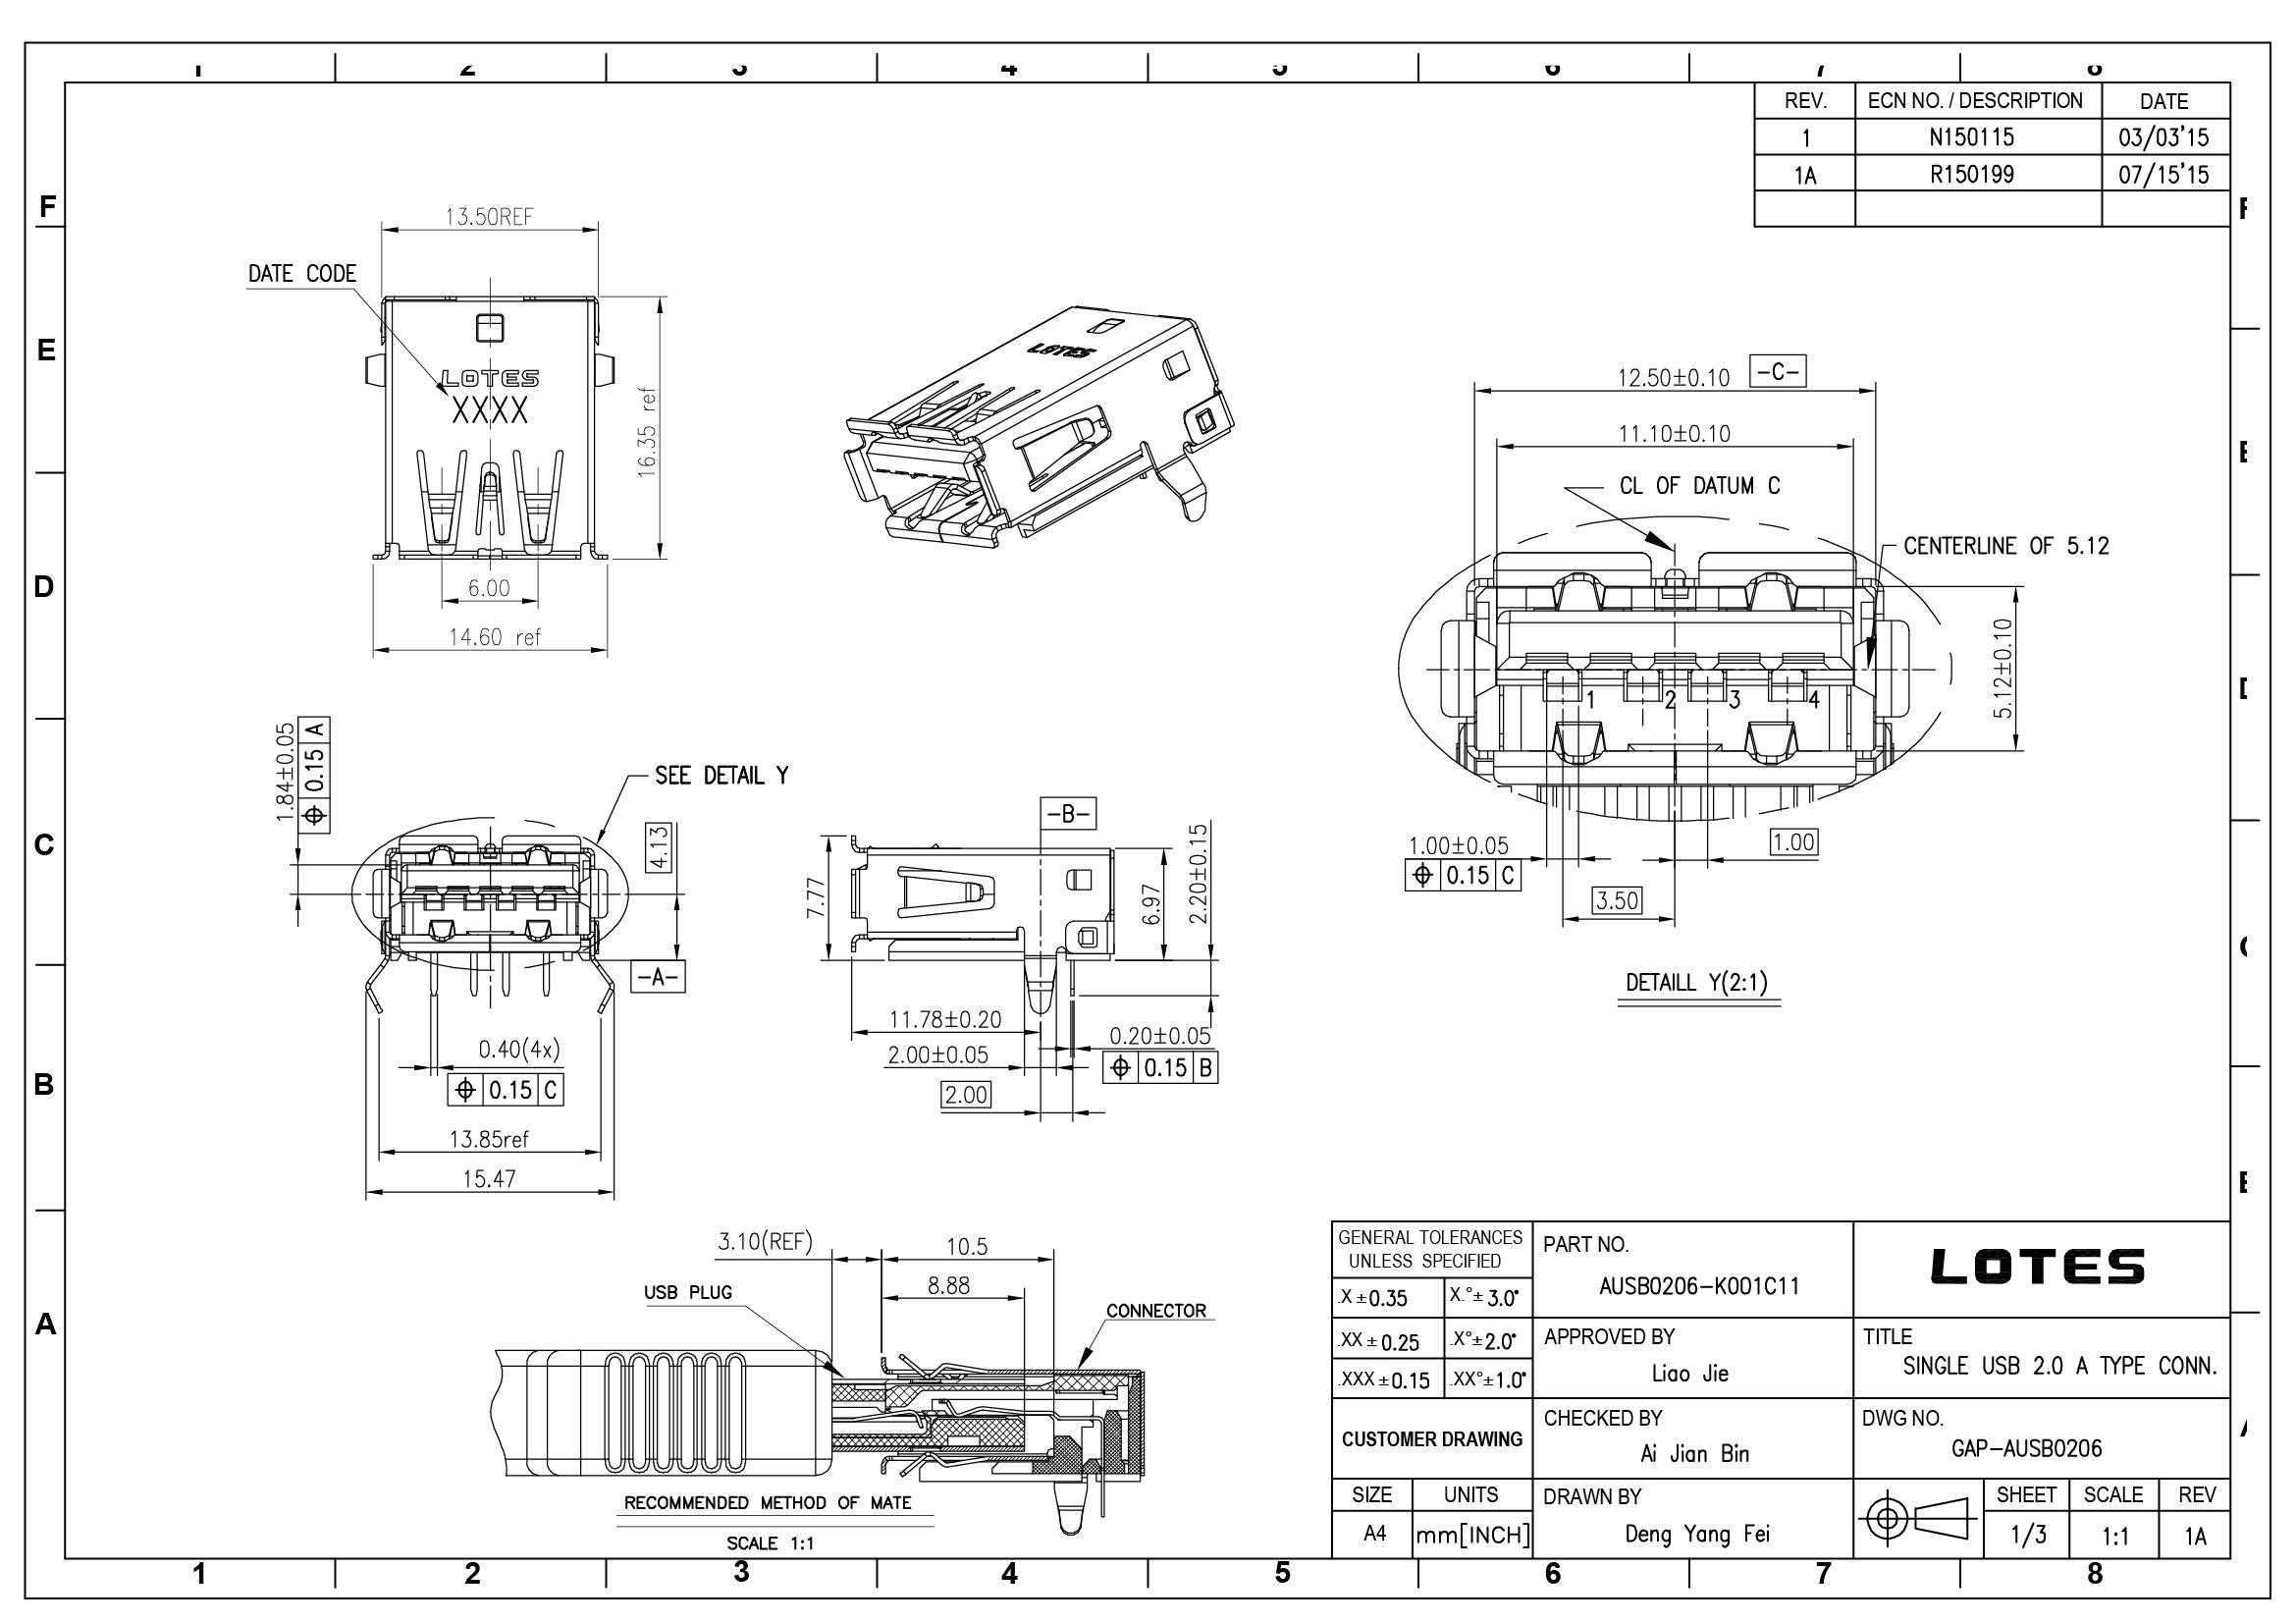


🖼️ /Volumes/jennifer_wang/usb_classification/page_images/57f4b058eb4464ab37c33f24989b207446698b6882d93d39920cf34d88a04293.jpg


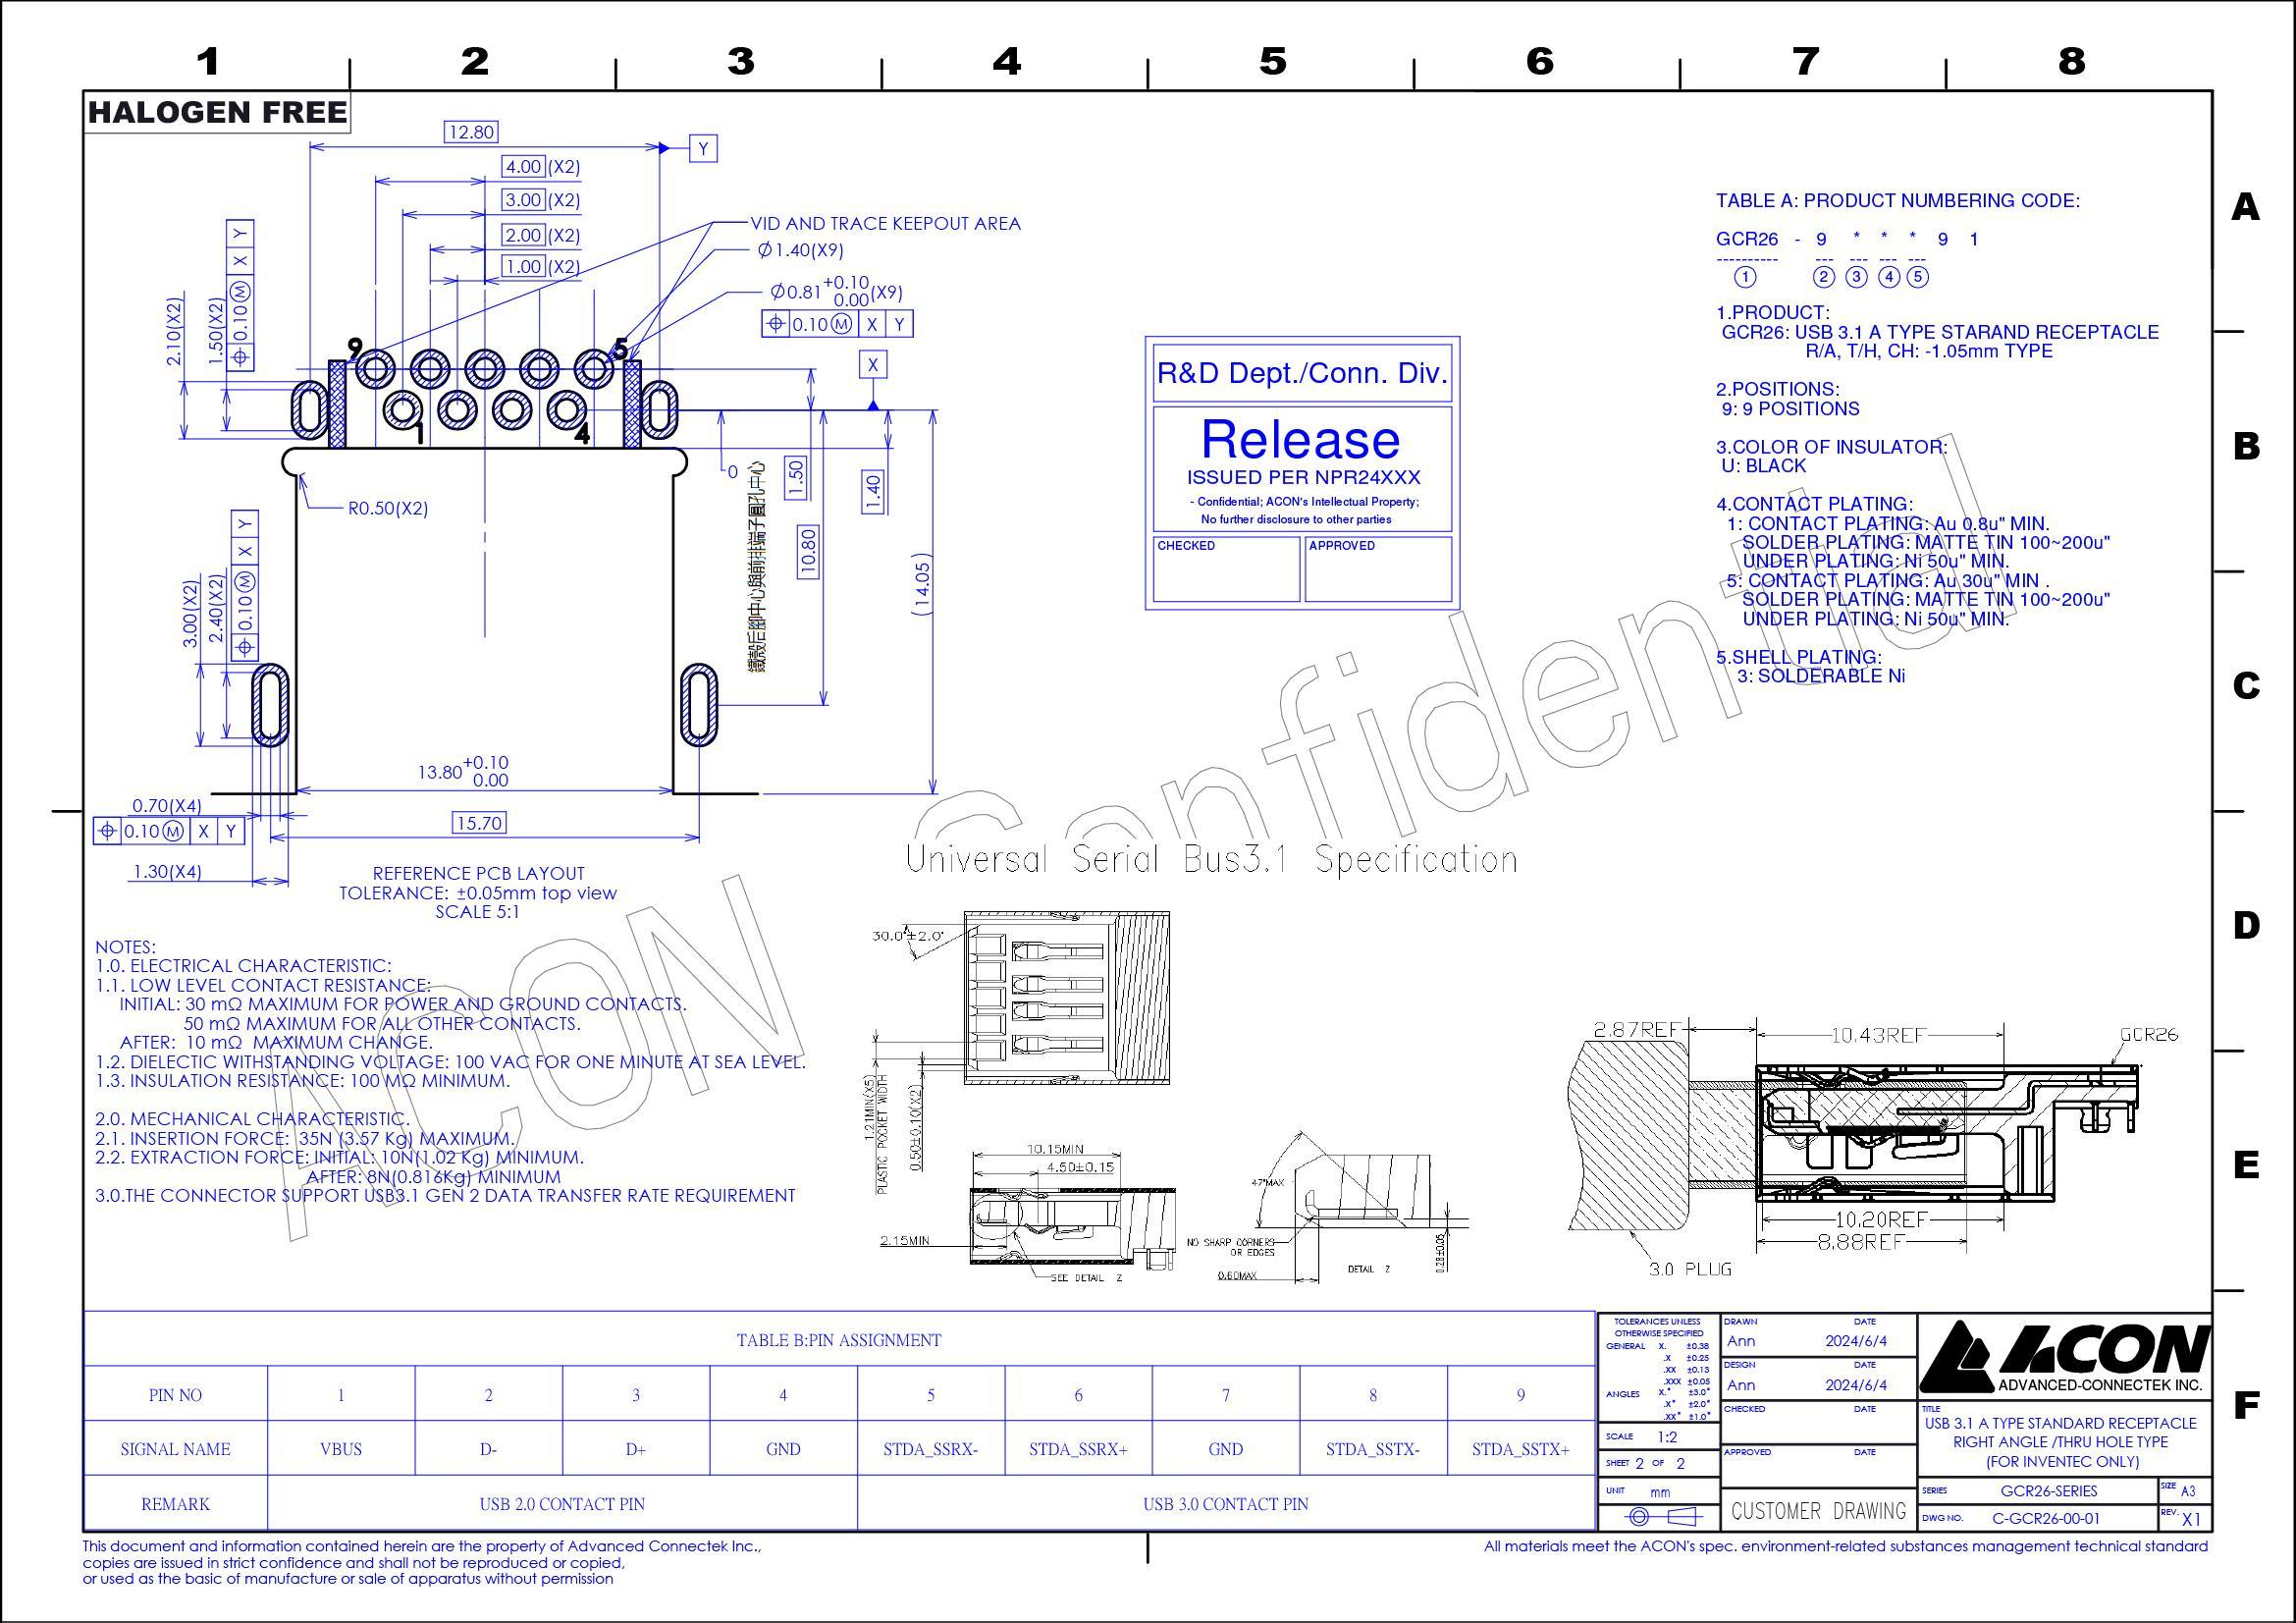


🖼️ /Volumes/jennifer_wang/usb_classification/page_images/b075a28e95ecd4fd23f746cd7f34344758c0190387f1770c4aaca7415b4422a3.jpg


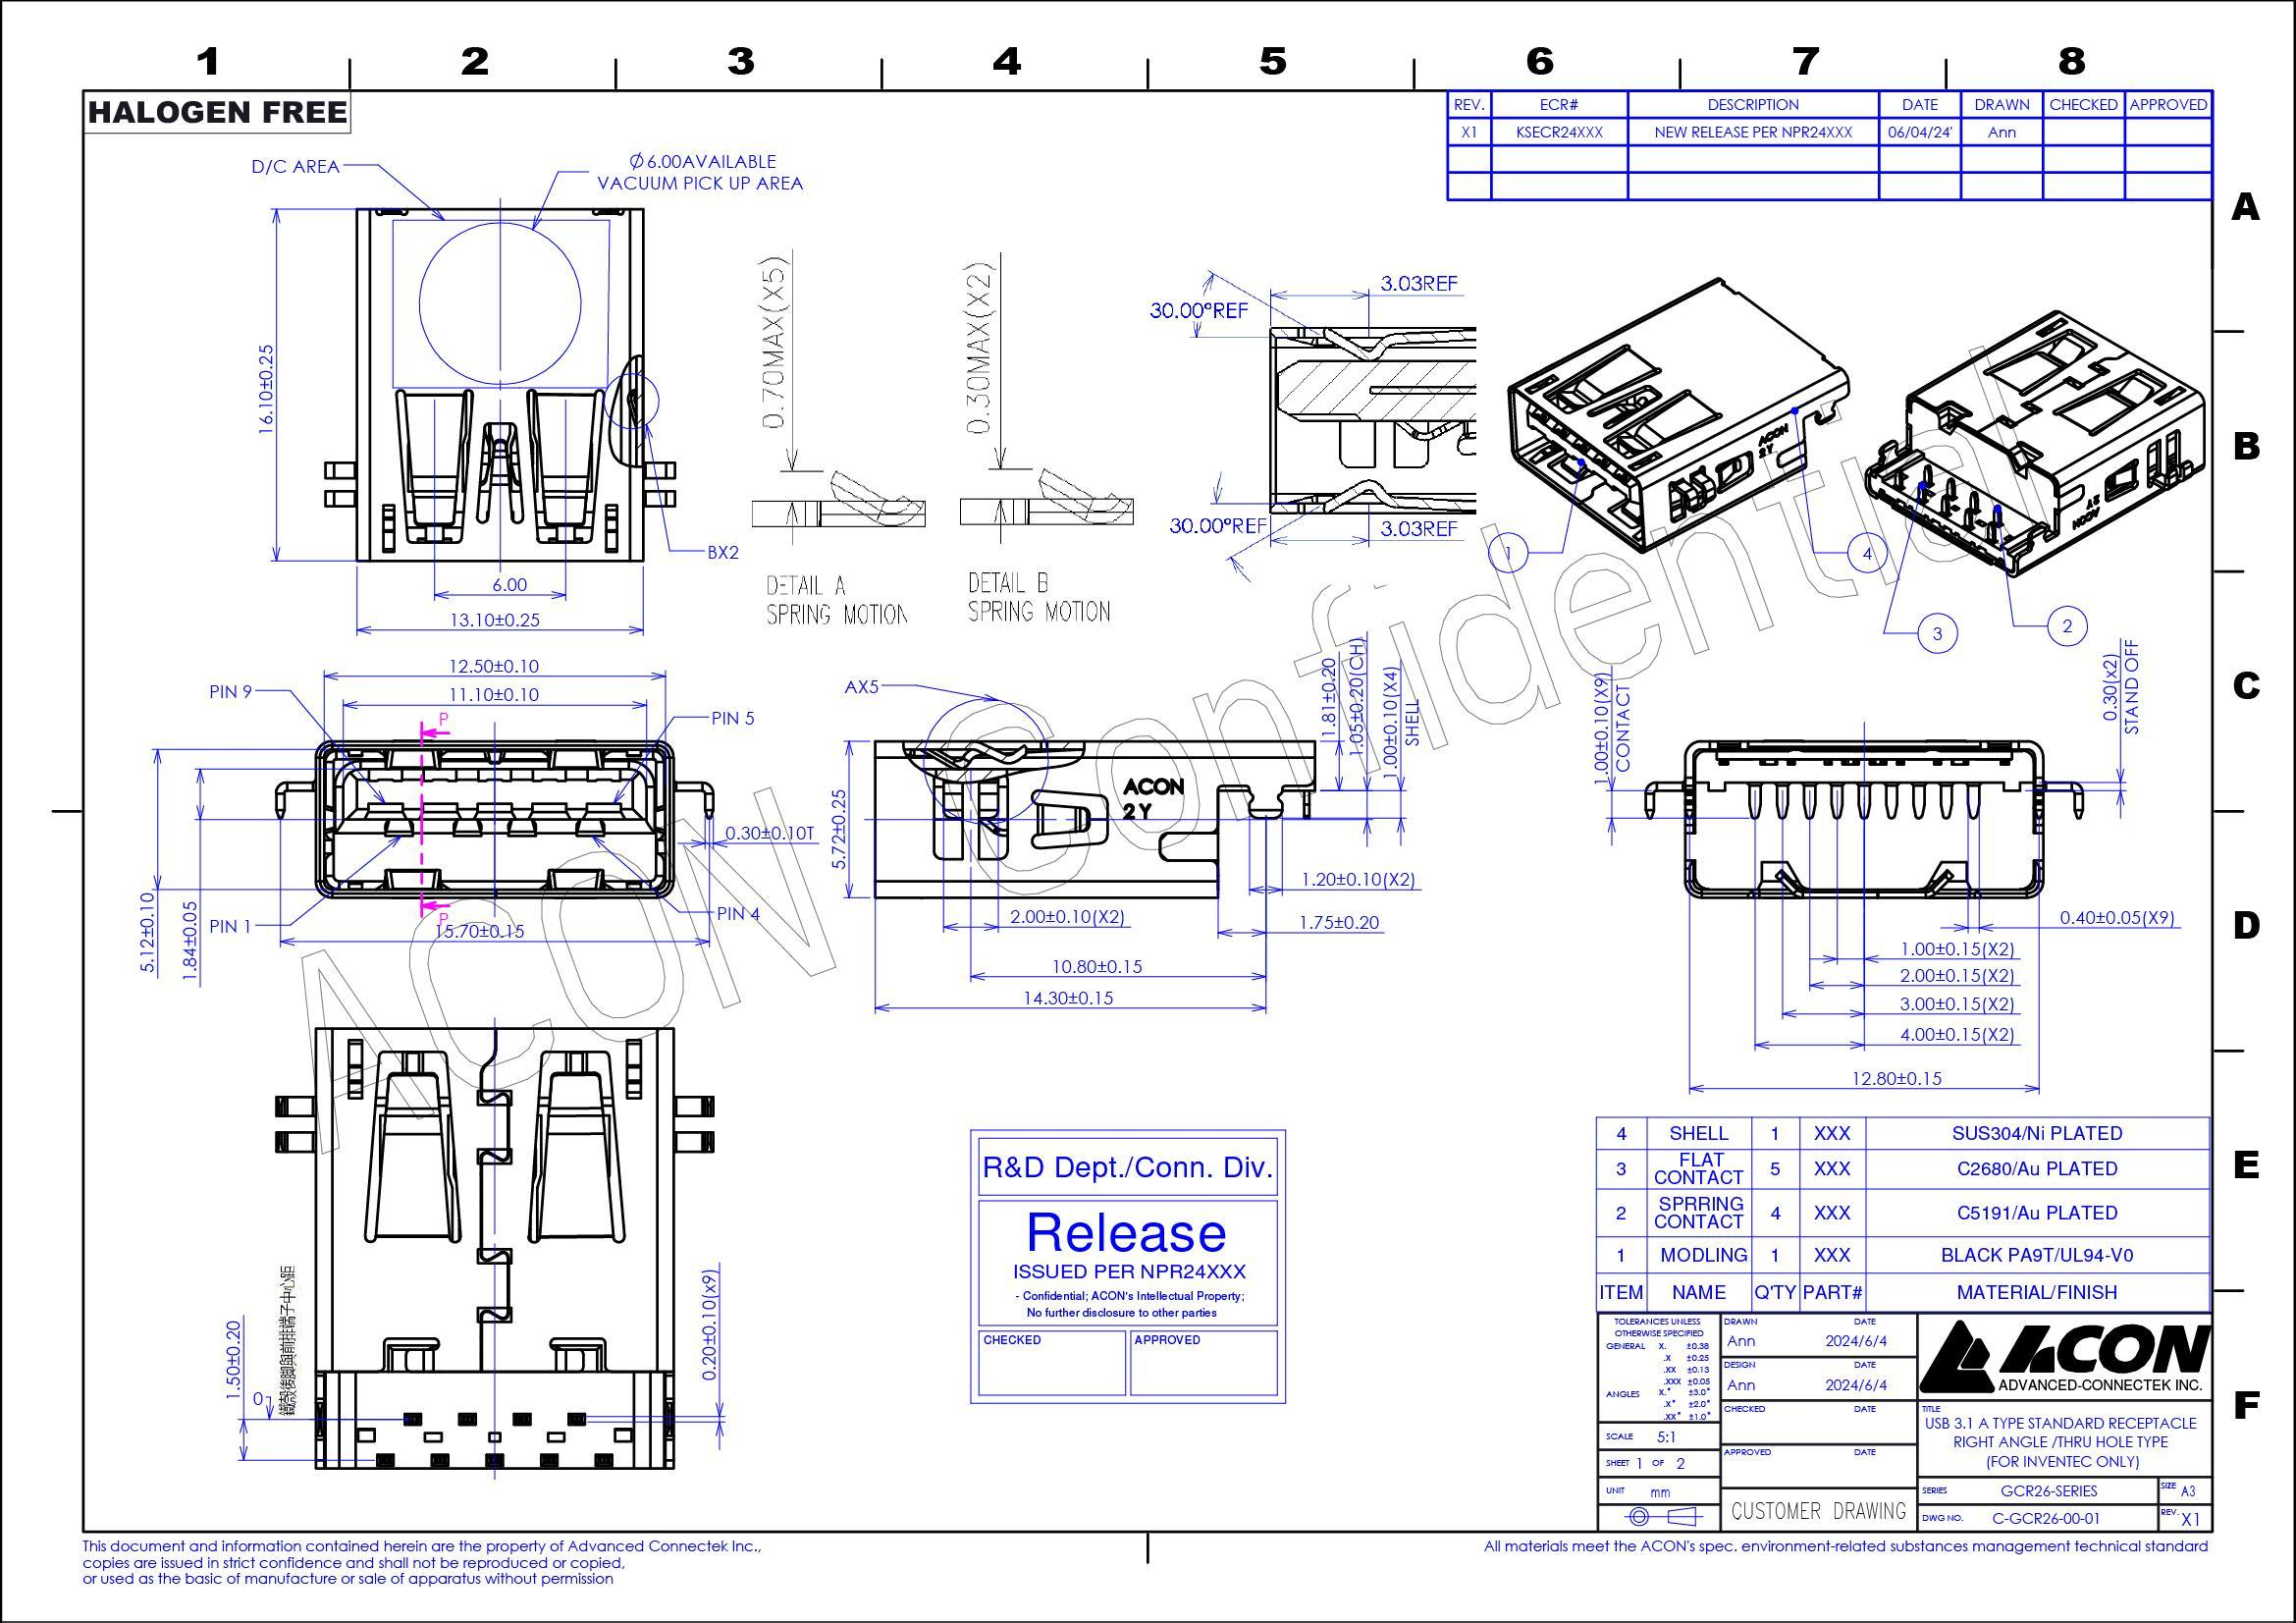

In [0]:
# Render the retrieved page image inline
from IPython.display import display, Image as IPImage

for uri in set(row[1].split(",")[0] for row in chunks):
    print(f"\n🖼️ {uri}")
    display(IPImage(filename=uri, width=600))


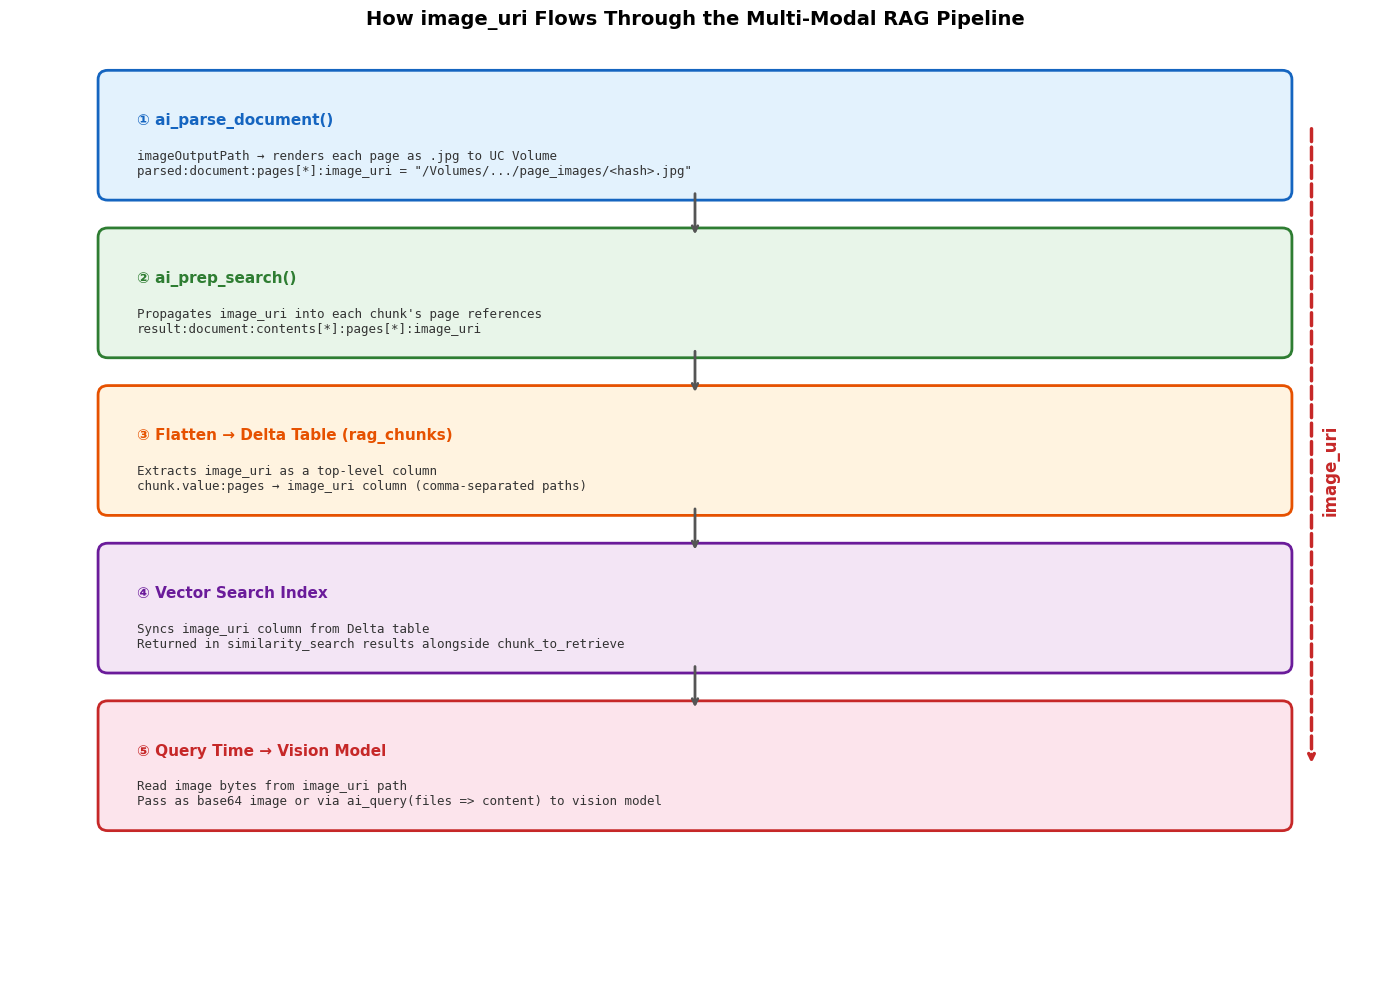

In [0]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 1, figsize=(14, 10))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('How image_uri Flows Through the Multi-Modal RAG Pipeline', fontsize=14, fontweight='bold', pad=20)

# Define boxes: (x, y, width, height, title, detail)
boxes = [
    (1, 8.5, 12, 1.2, '① ai_parse_document()', 
     'imageOutputPath → renders each page as .jpg to UC Volume\nparsed:document:pages[*]:image_uri = "/Volumes/.../page_images/<hash>.jpg"'),
    (1, 6.8, 12, 1.2, '② ai_prep_search()',
     'Propagates image_uri into each chunk\'s page references\nresult:document:contents[*]:pages[*]:image_uri'),
    (1, 5.1, 12, 1.2, '③ Flatten → Delta Table (rag_chunks)',
     'Extracts image_uri as a top-level column\nchunk.value:pages → image_uri column (comma-separated paths)'),
    (1, 3.4, 12, 1.2, '④ Vector Search Index',
     'Syncs image_uri column from Delta table\nReturned in similarity_search results alongside chunk_to_retrieve'),
    (1, 1.7, 12, 1.2, '⑤ Query Time → Vision Model',
     'Read image bytes from image_uri path\nPass as base64 image or via ai_query(files => content) to vision model'),
]

colors = ['#E3F2FD', '#E8F5E9', '#FFF3E0', '#F3E5F5', '#FCE4EC']
edge_colors = ['#1565C0', '#2E7D32', '#E65100', '#6A1B9A', '#C62828']

for i, (x, y, w, h, title, detail) in enumerate(boxes):
    rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1",
                                    facecolor=colors[i], edgecolor=edge_colors[i], linewidth=2)
    ax.add_patch(rect)
    ax.text(x + 0.3, y + h - 0.35, title, fontsize=11, fontweight='bold', color=edge_colors[i], va='top')
    ax.text(x + 0.3, y + 0.15, detail, fontsize=9, fontfamily='monospace', va='bottom', color='#333')

# Draw arrows between boxes
for i in range(len(boxes) - 1):
    ax.annotate('', xy=(7, boxes[i+1][1] + boxes[i+1][3]),
               xytext=(7, boxes[i][1]),
               arrowprops=dict(arrowstyle='->', color='#555', lw=2))

# Add image_uri label on the side
ax.text(13.5, 5.5, 'image_uri', fontsize=12, fontweight='bold', color='#C62828',
        rotation=90, ha='center', va='center')
ax.annotate('', xy=(13.3, 2.3), xytext=(13.3, 9.2),
            arrowprops=dict(arrowstyle='->', color='#C62828', lw=2.5, linestyle='--'))

plt.tight_layout()
plt.show()